# Checkpoint 1 

Neste checkpoint, o objetivo é testar dois modelos para classificação de textos:
1. Um modelo com implementação própria em NumPy;
2. Um modelo equivalente em PyTorch.

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

from activation import ReLUActivation, SigmoidActivation
from layers import DenseLayer, DropoutLayer
from losses import BinaryCrossEntropy
from neuralnetwork import NeuralNetwork

## Dataset

In [2]:
df = pd.read_csv("DatasetFinal/dataset_final.csv")
df.head()

,Text,source_name,source_code
0,By . Daily Mail Reporter . A former North Kore...,human,0
1,"i dont like working in teams, its too much hassle",human,0
2,We summarize a theoretical framework based o...,human,0
3,13 Disastrous Vending Machine FAILS (PHOTOS)\n...,meta,3
4,"However , net sales in 2010 are seen to have g...",human,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15555 entries, 0 to 15554
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Text         15555 non-null  str  
 1   source_name  15555 non-null  str  
 2   source_code  15555 non-null  int64
dtypes: int64(1), str(2)
memory usage: 24.8 MB


In [4]:
df["source_name"].value_counts()

source_name
human      7650
openai     2435
google     1900
meta       1838
mistral    1732
Name: count, dtype: int64

## Análise inicial do dataset

O dataset contém textos classificados por origem.  
As classes disponíveis são:

- human
- openai
- google
- meta
- mistral

Para esta primeira abordagem, vamos converter o problema para classificação binária:
- **human = 0**
- **qualquer modelo LLM = 1**

In [5]:
df["binary_label"] = (df["source_name"] != "human").astype(int)
df[["source_name", "binary_label"]].head()

df["binary_label"].value_counts()

#df["binary_label"].value_counts(normalize=True) * 100 #PERCENTAGEM

binary_label
1    7905
0    7650
Name: count, dtype: int64

## Visualização Gráfica

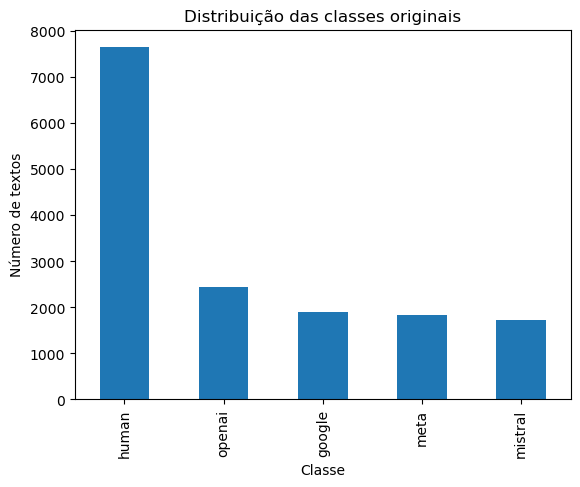

In [6]:
df["source_name"].value_counts().plot(kind="bar")
plt.title("Distribuição das classes originais")
plt.xlabel("Classe")
plt.ylabel("Número de textos")
plt.show()

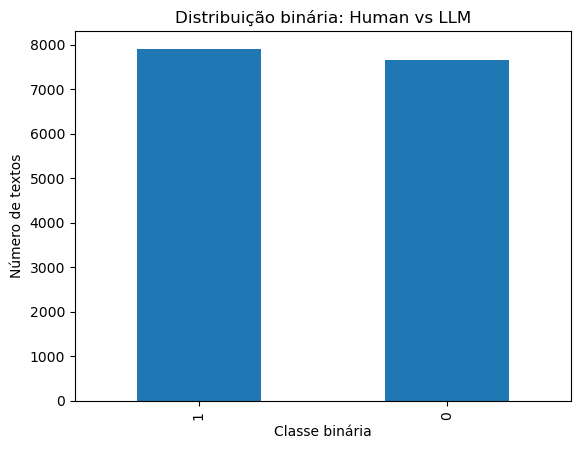

In [7]:
df["binary_label"].value_counts().plot(kind="bar")
plt.title("Distribuição binária: Human vs LLM")
plt.xlabel("Classe binária")
plt.ylabel("Número de textos")
plt.show()

## Pré-Processamento

In [8]:
X_text = df["Text"].astype(str)
y = df["binary_label"].values

In [9]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", len(X_train_text))
print("Test size:", len(X_test_text))

Train size: 12444
Test size: 3111


In [10]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X_train = vectorizer.fit_transform(X_train_text).toarray()
X_test = vectorizer.transform(X_test_text).toarray()

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (12444, 5000)
X_test shape: (3111, 5000)


In [11]:
# ajuste ao neuralnetwork.py

class SimpleDataset:
    def __init__(self, X, y):
        self.X = X
        self.y = y

train_data = SimpleDataset(X_train, y_train)
test_data = SimpleDataset(X_test, y_test)

## Criação e Treino Modelo Numpy

In [12]:
model = NeuralNetwork(
    epochs=20,
    batch_size=64,
    learning_rate=0.01,
    momentum=0.9,
    verbose=True,
    loss=BinaryCrossEntropy
)

model.add(DenseLayer(128, input_shape=(X_train.shape[1],)))
model.add(ReLUActivation())
model.add(DropoutLayer(0.3))
model.add(DenseLayer(1))
model.add(SigmoidActivation())

In [13]:
model.fit(train_data)

Epoch 1/20 - loss: 0.6926 - mean_squared_error: 0.2497
Epoch 2/20 - loss: 0.6917 - mean_squared_error: 0.2493
Epoch 3/20 - loss: 0.6904 - mean_squared_error: 0.2486
Epoch 4/20 - loss: 0.6892 - mean_squared_error: 0.2480
Epoch 5/20 - loss: 0.6878 - mean_squared_error: 0.2473
Epoch 6/20 - loss: 0.6863 - mean_squared_error: 0.2466
Epoch 7/20 - loss: 0.6847 - mean_squared_error: 0.2458
Epoch 8/20 - loss: 0.6829 - mean_squared_error: 0.2449
Epoch 9/20 - loss: 0.6809 - mean_squared_error: 0.2439
Epoch 10/20 - loss: 0.6789 - mean_squared_error: 0.2429
Epoch 11/20 - loss: 0.6766 - mean_squared_error: 0.2417
Epoch 12/20 - loss: 0.6739 - mean_squared_error: 0.2404
Epoch 13/20 - loss: 0.6711 - mean_squared_error: 0.2390
Epoch 14/20 - loss: 0.6686 - mean_squared_error: 0.2377
Epoch 15/20 - loss: 0.6654 - mean_squared_error: 0.2361
Epoch 16/20 - loss: 0.6622 - mean_squared_error: 0.2345
Epoch 17/20 - loss: 0.6589 - mean_squared_error: 0.2329
Epoch 18/20 - loss: 0.6548 - mean_squared_error: 0.2309
E

In [14]:
y_pred_prob = model.predict(test_data)
y_pred = (y_pred_prob >= 0.5).astype(int).flatten()

print(y_pred_prob[:10])
print(y_pred[:10])

[[0.4563702 ]
 [0.539927  ]
 [0.53219246]
 [0.55584216]
 [0.51312661]
 [0.43723836]
 [0.52920315]
 [0.47006956]
 [0.50280563]
 [0.49499416]]
[0 1 1 1 1 0 1 0 1 0]


In [15]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

print(classification_report(y_test, y_pred, target_names=["human", "LLM"]))

cm = confusion_matrix(y_test, y_pred)
print(cm)

Accuracy: 0.8379942140790743
Precision: 0.7737671581087952
Recall: 0.9626818469323213
F1-score: 0.8579481397970687
              precision    recall  f1-score   support

       human       0.95      0.71      0.81      1530
         LLM       0.77      0.96      0.86      1581

    accuracy                           0.84      3111
   macro avg       0.86      0.84      0.83      3111
weighted avg       0.86      0.84      0.84      3111

[[1085  445]
 [  59 1522]]


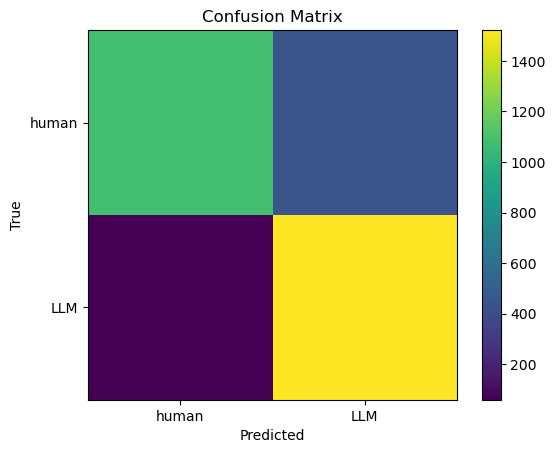

In [16]:
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0, 1], ["human", "LLM"])
plt.yticks([0, 1], ["human", "LLM"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

## Resultados do modelo (implementação própria)

O modelo obteve uma accuracy de aproximadamente **83.8%** na tarefa de distinguir textos humanos de textos gerados por LLM.

Observa-se um **recall muito elevado para a classe LLM (0.96)**, o que indica que o modelo consegue identificar a maioria dos textos gerados por modelos de linguagem.

No entanto, a matriz de confusão mostra que um número significativo de textos humanos é classificado como LLM. Isto sugere que o modelo tende a ser conservador, preferindo classificar textos ambíguos como gerados por LLM.

Mesmo assim, os resultados são consistentes para um primeiro modelo baseado em TF-IDF e uma rede neuronal simples.

## Modelo em PyTorch